# Car Price Prediction using Machine Learning

## Project Overview
This project predicts used car prices based on various features like brand, model, fuel type, kilometers driven, transmission type, and ownership history.

## Dataset
- **Source:** Indian used car market data
- **Records:** 5,050 cars
- **Features:** Brand & Model, Variant, Fuel Type, Kilometers Driven, Transmission, Owner, Location, Date
- **Target:** Price (in ₹)

## Project Structure
```
car-price-prediction/
├── data/
│   ├── raw/              # Original data
│   └── processed/        # Cleaned & split data
├── models/               # Trained models
├── images/              # Visualizations
│   ├── eda/
│   ├── model_performance/
│   └── predictions/
└── notebooks/           # This notebook
```

## Objective
Build a machine learning model to accurately predict car prices, helping buyers and sellers make informed decisions.

## Workflow
1. Data Understanding & EDA
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Train/Test Split
5. Model Building & Training
6. Model Evaluation & Comparison
7. Model Saving

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import re

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Load the dataset from raw data folder
df = pd.read_csv('data/raw/CarPrice.csv', encoding='utf-8-sig')

print("Dataset loaded successfully")
print(f"\nDataset Shape: {df.shape}")
print(f"Total Cars: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")


Dataset loaded successfully

Dataset Shape: (5050, 9)
Total Cars: 5,050
Total Features: 9


In [3]:
# First look at the data
df.head()

,Brand & Model,Varient,Fuel Type,Driven Kilometers,Transmission,Owner,Location,Date of Posting Ad,Price (in ₹)
0,Mahindra Xuv500 (2013),W8 Dual Tone,DIESEL,"58,000 KM",MANUAL,1st Owner,"Pitampura, Delhi",01/27/2022,435000
1,Hyundai Creta (2020),1.6 SX Option Executive Diesel,DIESEL,43861.0 KM,MANUAL,1st Owner,"Ahiritola, Kolkata",01/23/2022,1165101
2,Hyundai Verna (2019),VTVT 1.4 EX,PETROL,"17,000 KM",MANUAL,2nd Owner,"Chelavoor, Pantheeramkavu",01/25/2022,815000
3,Datsun Redigo (2020),D,PETROL,10000 KM,MANUAL,1st Owner,"Palam, Delhi",01/13/2022,270000
4,Hyundai I10 (2011),Sportz 1.1 iRDE2,PETROL,70000 KM,MANUAL,1st Owner,"Dwarka Sector 13, Delhi",01/13/2022,185000


In [4]:
# Check column namesand data types
print("Column Information:")
df.info()


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Brand & Model       5050 non-null   object
 1   Varient             5011 non-null   object
 2   Fuel Type           5050 non-null   object
 3   Driven Kilometers   5050 non-null   object
 4   Transmission        5050 non-null   object
 5   Owner               5050 non-null   object
 6   Location            5050 non-null   object
 7   Date of Posting Ad  5050 non-null   object
 8   Price (in ₹)        5050 non-null   int64 
dtypes: int64(1), object(8)
memory usage: 355.2+ KB


In [5]:
# Check for missing values
print("Missing values:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df =pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent.round(2)
})

print(missing_df[missing_df['Missing Count'] > 0])

Missing values:
         Missing Count  Percentage
Varient             39        0.77


---
## Exploratory Data Analysis

Let's explore the data to understand patterns and relationships.
---

In [6]:
# Basic statistics
df.describe()

,Price (in ₹)
count,5.050000e+03
mean,6.013569e+05
std,5.099877e+05
min,1.500000e+04
25%,3.615990e+05
50%,4.711990e+05
75%,6.783990e+05
max,7.175000e+06


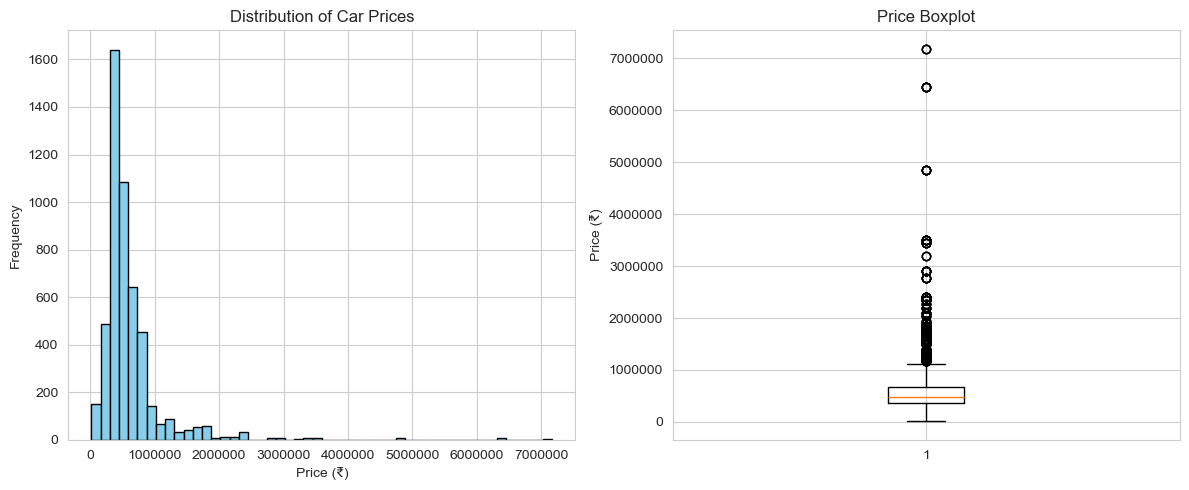

Average Price: ₹601,357
Median Price: ₹471,199
Minimum Price: ₹15,000
Maximum Price: ₹7,175,000


In [7]:
# Price distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Price (in ₹)'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')

plt.subplot(1, 2, 2)
plt.boxplot(df['Price (in ₹)'], vert=True)
plt.title('Price Boxplot')
plt.ylabel('Price (₹)')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('images/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average Price: ₹{df['Price (in ₹)'].mean():,.0f}")
print(f"Median Price: ₹{df['Price (in ₹)'].median():,.0f}")
print(f"Minimum Price: ₹{df['Price (in ₹)'].min():,}")
print(f"Maximum Price: ₹{df['Price (in ₹)'].max():,}")


In [8]:
# Extract Brand from "Brand & Model" column
df['Brand'] = df['Brand & Model'].str.split().str[0]

print("Unique Brands:", df['Brand'].nunique())
print("\nTop 10 Brands:")
print(df['Brand'].value_counts().head(10))


Unique Brands: 49

Top 10 Brands:
Brand
2017      669
2018      608
2015      588
2014      524
2013      472
2016      417
2019      390
Maruti    214
2012      201
2020      179
Name: count, dtype: int64


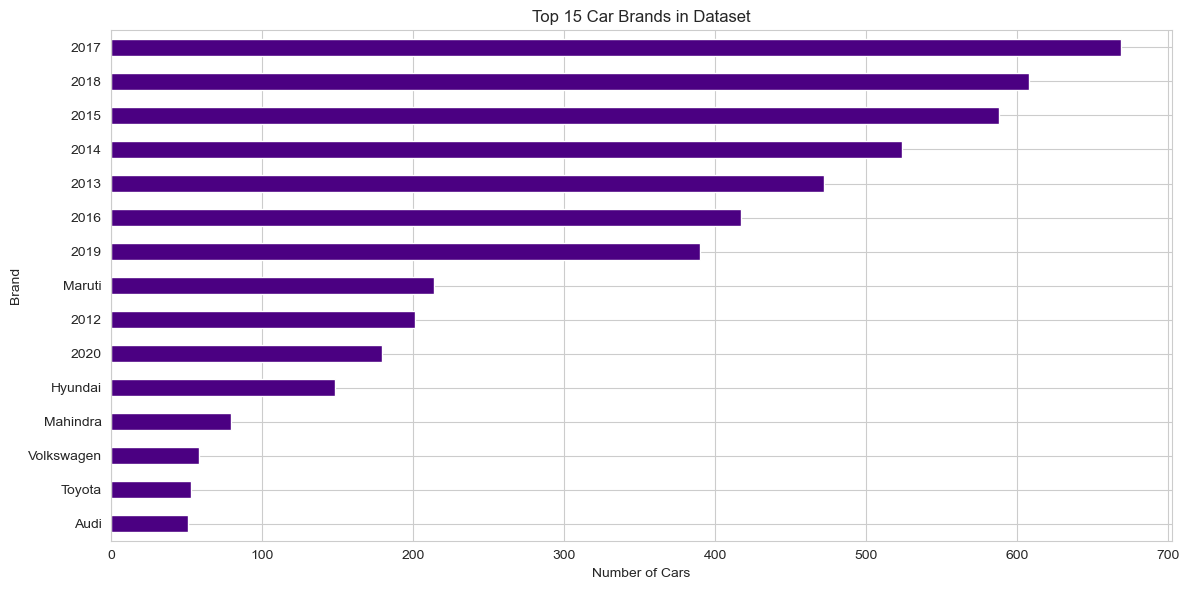

In [9]:
# Top 15 brands by count
top_brands = df['Brand'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_brands.plot(kind='barh',color='indigo')
plt.title('Top 15 Car Brands in Dataset')
plt.xlabel('Number of Cars')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/brand_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

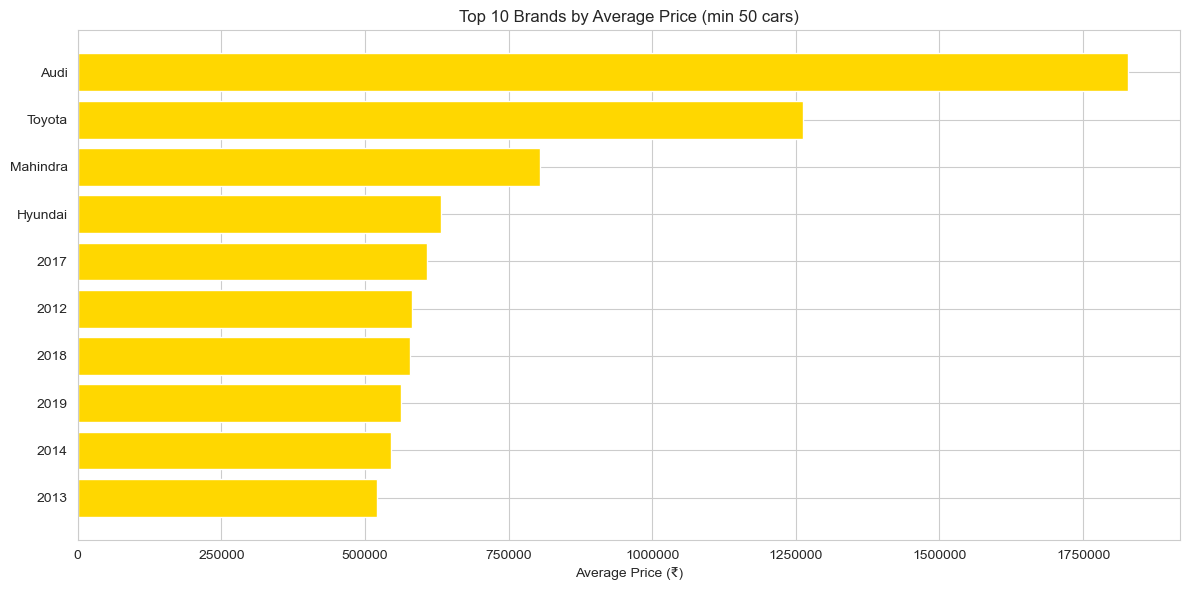

Top 10 Brands by Average Price:
Audi: ₹1,827,353 (51 cars)
Toyota: ₹1,263,302 (53 cars)
Mahindra: ₹804,899 (79 cars)
Hyundai: ₹633,094 (148 cars)
2017: ₹607,963 (669 cars)
2012: ₹581,955 (201 cars)
2018: ₹577,724 (608 cars)
2019: ₹563,016 (390 cars)
2014: ₹545,794 (524 cars)
2013: ₹520,706 (472 cars)


In [10]:
# Average price by brand (top 10 brands)
brand_avg_price = df.groupby('Brand')['Price (in ₹)'].agg(['mean', 'count'])
brand_avg_price = brand_avg_price[brand_avg_price['count'] >= 50]
brand_avg_price = brand_avg_price.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(brand_avg_price.index, brand_avg_price['mean'], color='gold')
plt.xlabel('Average Price (₹)')
plt.title('Top 10 Brands by Average Price (min 50 cars)')
plt.gca().invert_yaxis()
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('images/brand_price_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 Brands by Average Price:")
for brand, row in brand_avg_price.iterrows():
    print(f"{brand}: ₹{row['mean']:,.0f} ({int(row['count'])} cars)")

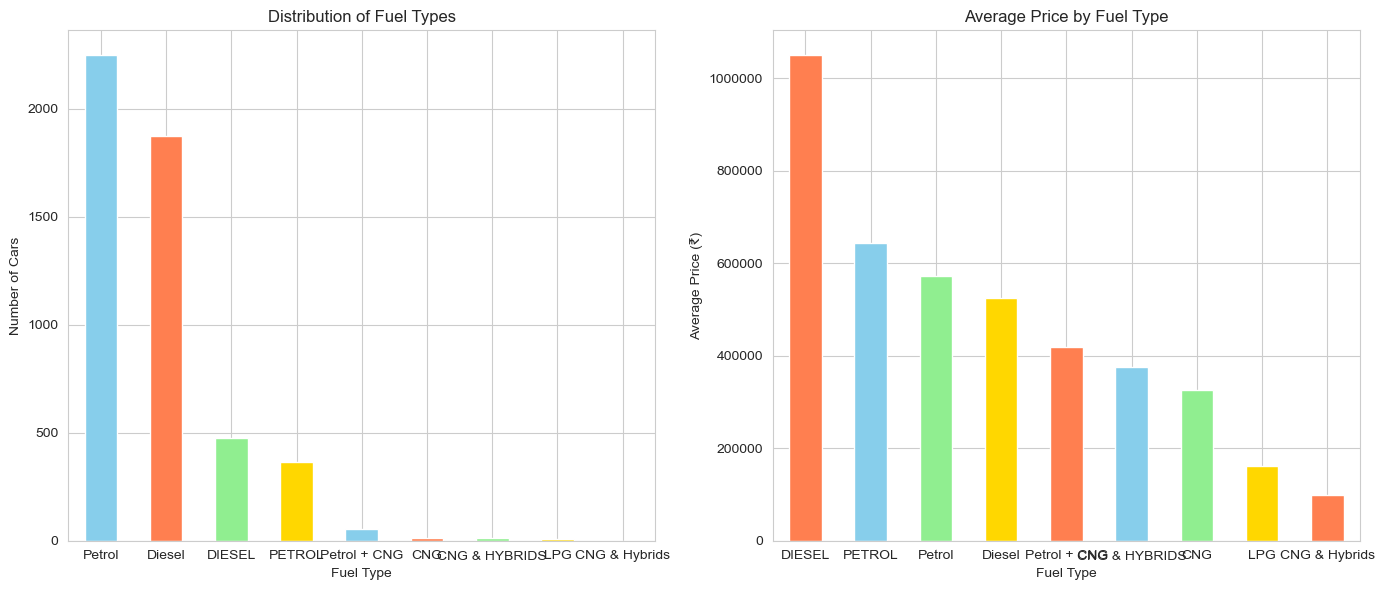

Fuel Type Distribution:
Petrol: 2249 cars, Avg Price: ₹572,484
Diesel: 1872 cars, Avg Price: ₹524,350
DIESEL: 475 cars, Avg Price: ₹1,050,724
PETROL: 366 cars, Avg Price: ₹643,964
Petrol + CNG: 55 cars, Avg Price: ₹417,870
CNG: 13 cars, Avg Price: ₹326,077
CNG & HYBRIDS: 12 cars, Avg Price: ₹376,250
LPG: 7 cars, Avg Price: ₹161,429
CNG & Hybrids: 1 cars, Avg Price: ₹99,000


In [11]:
# Fuel Type analysis
fuel_counts = df['Fuel Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
fuel_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'coral', 'lightgreen', 'gold'])
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Fuel Types')
axes[0].set_xticklabels(fuel_counts.index, rotation=0)

# Average price by fuel type
fuel_avg_price = df.groupby('Fuel Type')['Price (in ₹)'].mean().sort_values(ascending=False)
fuel_avg_price.plot(kind='bar', ax=axes[1], color=['coral', 'skyblue', 'lightgreen', 'gold'])
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Average Price (₹)')
axes[1].set_title('Average Price by Fuel Type')
axes[1].set_xticklabels(fuel_avg_price.index, rotation=0)
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('images/fuel_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Fuel Type Distribution:")
for fuel, count in fuel_counts.items():
    avg_price = df[df['Fuel Type'] == fuel]['Price (in ₹)'].mean()
    print(f"{fuel}: {count} cars, Avg Price: ₹{avg_price:,.0f}")

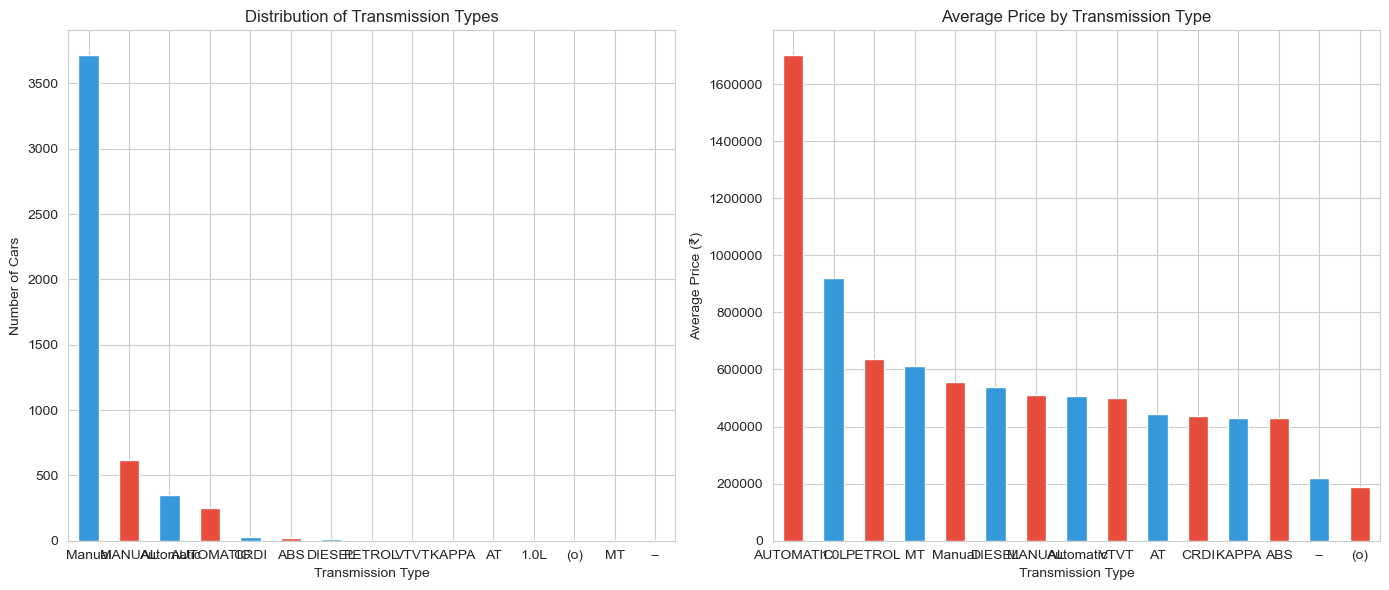

Transmission Type Analysis:
Manual: 3719 cars, Avg Price: ₹554,439
MANUAL: 618 cars, Avg Price: ₹511,497
Automatic: 350 cars, Avg Price: ₹506,759
AUTOMATIC: 251 cars, Avg Price: ₹1,702,689
CRDI: 31 cars, Avg Price: ₹437,815
ABS: 23 cars, Avg Price: ₹429,834
DIESEL: 12 cars, Avg Price: ₹539,399
PETROL: 9 cars, Avg Price: ₹637,099
VTVT: 6 cars, Avg Price: ₹498,599
KAPPA: 6 cars, Avg Price: ₹429,999
AT: 6 cars, Avg Price: ₹443,799
1.0L: 6 cars, Avg Price: ₹921,799
(o): 6 cars, Avg Price: ₹186,971
MT: 5 cars, Avg Price: ₹610,899
--: 2 cars, Avg Price: ₹220,000


In [12]:
# Transmission analysis
trans_counts = df['Transmission'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
trans_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_xlabel('Transmission Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Transmission Types')
axes[0].set_xticklabels(trans_counts.index, rotation=0)

# Average price by transmission
trans_avg_price = df.groupby('Transmission')['Price (in ₹)'].mean().sort_values(ascending=False)
trans_avg_price.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Average Price (₹)')
axes[1].set_title('Average Price by Transmission Type')
axes[1].set_xticklabels(trans_avg_price.index, rotation=0)
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('images/transmission_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Transmission Type Analysis:")
for trans, count in trans_counts.items():
    avg_price = df[df['Transmission'] == trans]['Price (in ₹)'].mean()
    print(f"{trans}: {count} cars, Avg Price: ₹{avg_price:,.0f}")

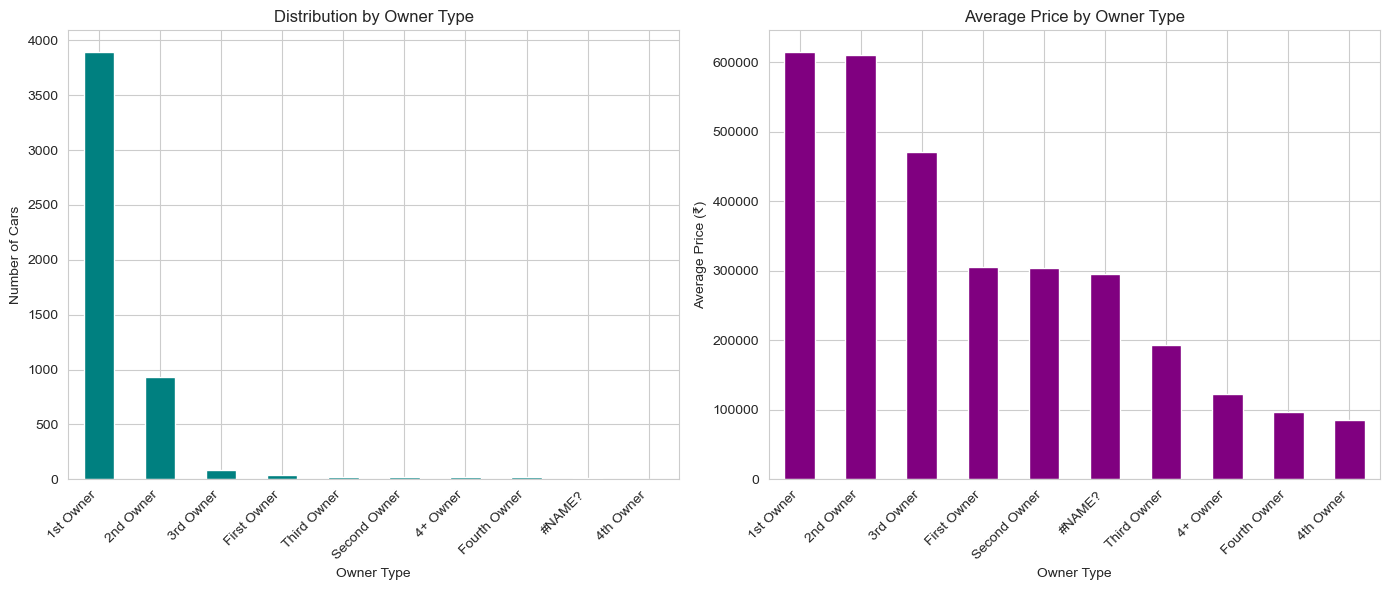

Owner Type Analysis:
1st Owner: 3895 cars, Avg Price: ₹615,240
2nd Owner: 935 cars, Avg Price: ₹611,308
3rd Owner: 80 cars, Avg Price: ₹471,183
First Owner: 39 cars, Avg Price: ₹305,897
Third Owner: 24 cars, Avg Price: ₹193,749
Second Owner: 21 cars, Avg Price: ₹304,000
4+ Owner: 20 cars, Avg Price: ₹122,200
Fourth Owner: 18 cars, Avg Price: ₹97,500
#NAME?: 12 cars, Avg Price: ₹296,000
4th Owner: 6 cars, Avg Price: ₹85,000


In [13]:
# Owner analysis
owner_counts = df['Owner'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
owner_counts.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_xlabel('Owner Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution by Owner Type')
axes[0].set_xticklabels(owner_counts.index, rotation=45, ha='right')

# Average price by owner
owner_avg_price = df.groupby('Owner')['Price (in ₹)'].mean().sort_values(ascending=False)
owner_avg_price.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_xlabel('Owner Type')
axes[1].set_ylabel('Average Price (₹)')
axes[1].set_title('Average Price by Owner Type')
axes[1].set_xticklabels(owner_avg_price.index, rotation=45, ha='right')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('images/owner_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Owner Type Analysis:")
for owner, count in owner_counts.items():
    avg_price = df[df['Owner'] == owner]['Price (in ₹)'].mean()
    print(f"{owner}: {count} cars, Avg Price: ₹{avg_price:,.0f}")

## Key Observations from EDA:

1. **Price Distribution:** Most cars are priced between ₹3-7 lakhs, with some outliers above ₹30 lakhs
2. **Top Brands:** Maruti Suzuki dominates the market, followed by Hyundai and Mahindra
3. **Fuel Type:** PETROL and DIESEL cars are most common. DIESEL cars have higher average prices
4. **Transmission:** MANUAL transmission is more common but AUTOMATIC cars are pricier
5. **Ownership:** 1st Owner cars are most common and command higher prices

Now let's clean and prepare the data for modeling!

---
## Data Cleaning & Preprocessing
---

In [14]:
# Create a copy for processing

In [15]:
df_clean = df.copy()

print("Starting data cleaning..")
print(f"Original shape: {df_clean.shape}")


Starting data cleaning..
Original shape: (5050, 10)


In [16]:
# 1. Fix "Driven Kilometers" - remove commas and convert to numeric
df_clean['Driven Kilometers'] = df_clean['Driven Kilometers'].str.replace(',', '')
df_clean['Driven Kilometers'] = df_clean['Driven Kilometers'].str.replace(' KM', '')
df_clean['Driven Kilometers'] = pd.to_numeric(df_clean['Driven Kilometers'], errors='coerce')

print("Fixed Driven Kilometers column")
print(f"Sample values: {df_clean['Driven Kilometers'].head()}")

Fixed Driven Kilometers column
Sample values: 0    58000.0
1    43861.0
2    17000.0
3    10000.0
4    70000.0
Name: Driven Kilometers, dtype: float64


In [17]:
# 2. Extract Year from "Brand & Model" column
def extract_year(text):
    """Extract year from text like 'Maruti Suzuki Swift (2016)'"""
    match = re.search(r'\((\d{4})\)', text)
    if match:
        return int(match.group(1))
    return None

df_clean['Year'] = df_clean['Brand & Model'].apply(extract_year)

print("Extracted Year from Brand & Model")
print(f"Years range: {df_clean['Year'].min()} to {df_clean['Year'].max()}")
print(f"Missing years: {df_clean['Year'].isnull().sum()}")


Extracted Year from Brand & Model
Years range: 1970.0 to 2021.0
Missing years: 4138


In [18]:
# 3. Calculate Car Age (2022 - Year)
current_year = 2022  # Based on the dataset posting dates
df_clean['Car_Age'] = current_year - df_clean['Year']

print("Calculated Car Age")
print(f"Age range: {df_clean['Car_Age'].min()} to {df_clean['Car_Age'].max()} years")

Calculated Car Age
Age range: 1.0 to 52.0 years


In [19]:
# 4. Extract Brand 
df_clean['Brand'] = df_clean['Brand & Model'].str.split().str[0]

print("Extracted Brand")
print(f"Unique brands: {df_clean['Brand'].nunique()}")

Extracted Brand
Unique brands: 49


In [20]:
# 5. Handle missing values
print("Missing values before handling:")
print(df_clean.isnull().sum())

# Drop rows with missing Year (can't calculate age without year)
df_clean = df_clean.dropna(subset=['Year'])

# Fill missing Variant with 'Unknown'
df_clean['Varient'].fillna('Unknown', inplace=True)

print("\nHandled missing values")
print(f"Shape after cleaning: {df_clean.shape}")

Missing values before handling:
Brand & Model            0
Varient                 39
Fuel Type                0
Driven Kilometers     4179
Transmission             0
Owner                    0
Location                 0
Date of Posting Ad       0
Price (in ₹)             0
Brand                    0
Year                  4138
Car_Age               4138
dtype: int64

Handled missing values
Shape after cleaning: (912, 12)


In [21]:
# 6. Save cleaned data
df_clean.to_csv('data/processed/cleaned_data.csv', index=False)
print("Saved cleaned data to data/processed/cleaned_data.csv")

Saved cleaned data to data/processed/cleaned_data.csv


---
## Feature Engineering
---

In [22]:
# Select features for modeling
features_to_use = [
    'Brand',
    'Fuel Type', 
    'Driven Kilometers',
    'Transmission',
    'Owner',
    'Car_Age',
    'Price (in ₹)'  # Target variable
]

df_model = df_clean[features_to_use].copy()

print("Selected features for modeling")
print(f"Dataset shape: {df_model.shape}")
print(f"\nFeatures: {features_to_use[:-1]}")
print(f"Target: {features_to_use[-1]}")

Selected features for modeling
Dataset shape: (912, 7)

Features: ['Brand', 'Fuel Type', 'Driven Kilometers', 'Transmission', 'Owner', 'Car_Age']
Target: Price (in ₹)


In [23]:
# Check data before encoding
print("Data before encoding:")
print(df_model.head())
print("\nData types:")
print(df_model.dtypes)

Data before encoding:
      Brand Fuel Type  Driven Kilometers Transmission      Owner  Car_Age  \
0  Mahindra    DIESEL            58000.0       MANUAL  1st Owner      9.0   
1   Hyundai    DIESEL            43861.0       MANUAL  1st Owner      2.0   
2   Hyundai    PETROL            17000.0       MANUAL  2nd Owner      3.0   
3    Datsun    PETROL            10000.0       MANUAL  1st Owner      2.0   
4   Hyundai    PETROL            70000.0       MANUAL  1st Owner     11.0   

   Price (in ₹)  
0        435000  
1       1165101  
2        815000  
3        270000  
4        185000  

Data types:
Brand                 object
Fuel Type             object
Driven Kilometers    float64
Transmission          object
Owner                 object
Car_Age              float64
Price (in ₹)           int64
dtype: object


In [24]:
# Encode categorical variables

# First, let's check for any missing values before encoding
print("Checking for missing values before encoding:")
print(df_model.isnull().sum())
print()

# Drop any rows with missing values
df_model = df_model.dropna()
print(f"Dropped rows with missing values")
print(f"New shape: {df_model.shape}")
print()

# Initialize label encoders dictionary
label_encoders = {}

categorical_columns = ['Brand', 'Fuel Type', 'Transmission', 'Owner']

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

print("\nAll categorical variables encoded!")

Checking for missing values before encoding:
Brand                 0
Fuel Type             0
Driven Kilometers    41
Transmission          0
Owner                 0
Car_Age               0
Price (in ₹)          0
dtype: int64

Dropped rows with missing values
New shape: (871, 7)

Encoded Brand: 22 unique values
Encoded Fuel Type: 5 unique values
Encoded Transmission: 3 unique values
Encoded Owner: 10 unique values

All categorical variables encoded!


In [25]:
# Check data after encoding
print("Data after encoding:")
print(df_model.head(10))

Data after encoding:
   Brand  Fuel Type  Driven Kilometers  Transmission  Owner  Car_Age  \
0     10          2            58000.0             2      1      9.0   
1      7          2            43861.0             2      1      2.0   
2      7          4            17000.0             2      2      3.0   
3      3          4            10000.0             2      1      2.0   
4      7          4            70000.0             2      1     11.0   
5     19          2           140000.0             2      2     11.0   
6     11          4            22464.0             2      1      5.0   
7     10          2            58000.0             2      1      9.0   
8     11          4            84000.0             2      1      6.0   
9     11          2            93000.0             2      1      9.0   

   Price (in ₹)  
0        435000  
1       1165101  
2        815000  
3        270000  
4        185000  
5        740000  
6        418500  
7        435000  
8        480000  
9     

---
## Train-Test Split
---

In [26]:
# Separate features (X) and target (y)
X = df_model.drop('Price (in ₹)', axis=1)
y = df_model['Price (in ₹)']

print("Features (X):")
print(X.head())
print(f"\nShape: {X.shape}")

print("\n" + "="*60)

print("\nTarget (y):")
print(y.head())
print(f"Shape: {y.shape}")

Features (X):
   Brand  Fuel Type  Driven Kilometers  Transmission  Owner  Car_Age
0     10          2            58000.0             2      1      9.0
1      7          2            43861.0             2      1      2.0
2      7          4            17000.0             2      2      3.0
3      3          4            10000.0             2      1      2.0
4      7          4            70000.0             2      1     11.0

Shape: (871, 6)


Target (y):
0     435000
1    1165101
2     815000
3     270000
4     185000
Name: Price (in ₹), dtype: int64
Shape: (871,)


In [27]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Data split into train and test sets")
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Data split into train and test sets

Training set: 696 samples (79.9%)
Test set: 175 samples (20.1%)


In [28]:
# Feature Scaling - normalize features for better model performance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"\nOriginal feature range example (Driven Kilometers):")
print(f"  Min: {X_train['Driven Kilometers'].min():,.0f}")
print(f"  Max: {X_train['Driven Kilometers'].max():,.0f}")

print(f"\nScaled feature range:")
print(f"  Min: {X_train_scaled[:, 2].min():.2f}")
print(f"  Max: {X_train_scaled[:, 2].max():.2f}")

Features scaled using StandardScaler

Original feature range example (Driven Kilometers):
  Min: 0
  Max: 206,167

Scaled feature range:
  Min: -1.70
  Max: 3.06


In [29]:
# Save train and test data
train_data = pd.concat([
    pd.DataFrame(X_train_scaled, columns=X.columns),
    pd.Series(y_train.values, name='Price (in ₹)')
], axis=1)

test_data = pd.concat([
    pd.DataFrame(X_test_scaled, columns=X.columns),
    pd.Series(y_test.values, name='Price (in ₹)')
], axis=1)

train_data.to_csv('data/processed/train_data.csv', index=False)
test_data.to_csv('data/processed/test_data.csv', index=False)

print("Saved train and test data")
print(f"  - data/processed/train_data.csv")
print(f"  - data/processed/test_data.csv")

Saved train and test data
  - data/processed/train_data.csv
  - data/processed/test_data.csv


---
## Model Building & Training

We'll train 3 different models and compare their performance:
1. **Linear Regression** - Simple baseline model
2. **Random Forest** - Ensemble learning with decision trees
3. **Gradient Boosting** - Advanced boosting algorithm
---

In [30]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("Initialized 3 models:")
for name in models.keys():
    print(f"  - {name}")

Initialized 3 models:
  - Linear Regression
  - Random Forest
  - Gradient Boosting


In [31]:
# Train all models and store results
results = {}

print("Training models...\n")

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'rmse': test_rmse,
        'mae': test_mae,
        'predictions': y_test_pred
    }
    
    print(f"{name} trained!")
    print(f"   Train R² Score: {train_r2:.4f}")
    print(f"   Test R² Score: {test_r2:.4f}")
    print(f"   RMSE: ₹{test_rmse:,.0f}")
    print(f"   MAE: ₹{test_mae:,.0f}")

print("All models trained successfully!")

Training models...


Training Linear Regression...
Linear Regression trained!
   Train R² Score: 0.4270
   Test R² Score: 0.3588
   RMSE: ₹885,400
   MAE: ₹523,642

Training Random Forest...
Random Forest trained!
   Train R² Score: 0.9932
   Test R² Score: 0.9801
   RMSE: ₹156,004
   MAE: ₹40,410

Training Gradient Boosting...
Gradient Boosting trained!
   Train R² Score: 0.9700
   Test R² Score: 0.9632
   RMSE: ₹212,170
   MAE: ₹142,598
All models trained successfully!


In [32]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [results[m]['train_r2'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'RMSE': [results[m]['rmse'] for m in results.keys()],
    'MAE': [results[m]['mae'] for m in results.keys()]
})

print("Model Performance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))

# Find best model based on Test R²
best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
print(f"\nBest Model: {best_model_name}")

Model Performance Comparison:
            Model  Train R²  Test R²          RMSE           MAE
Linear Regression  0.426980 0.358768 885400.388928 523642.042911
    Random Forest  0.993244 0.980093 156003.755255  40409.968851
Gradient Boosting  0.970023 0.963178 212170.232183 142597.561903

Best Model: Random Forest


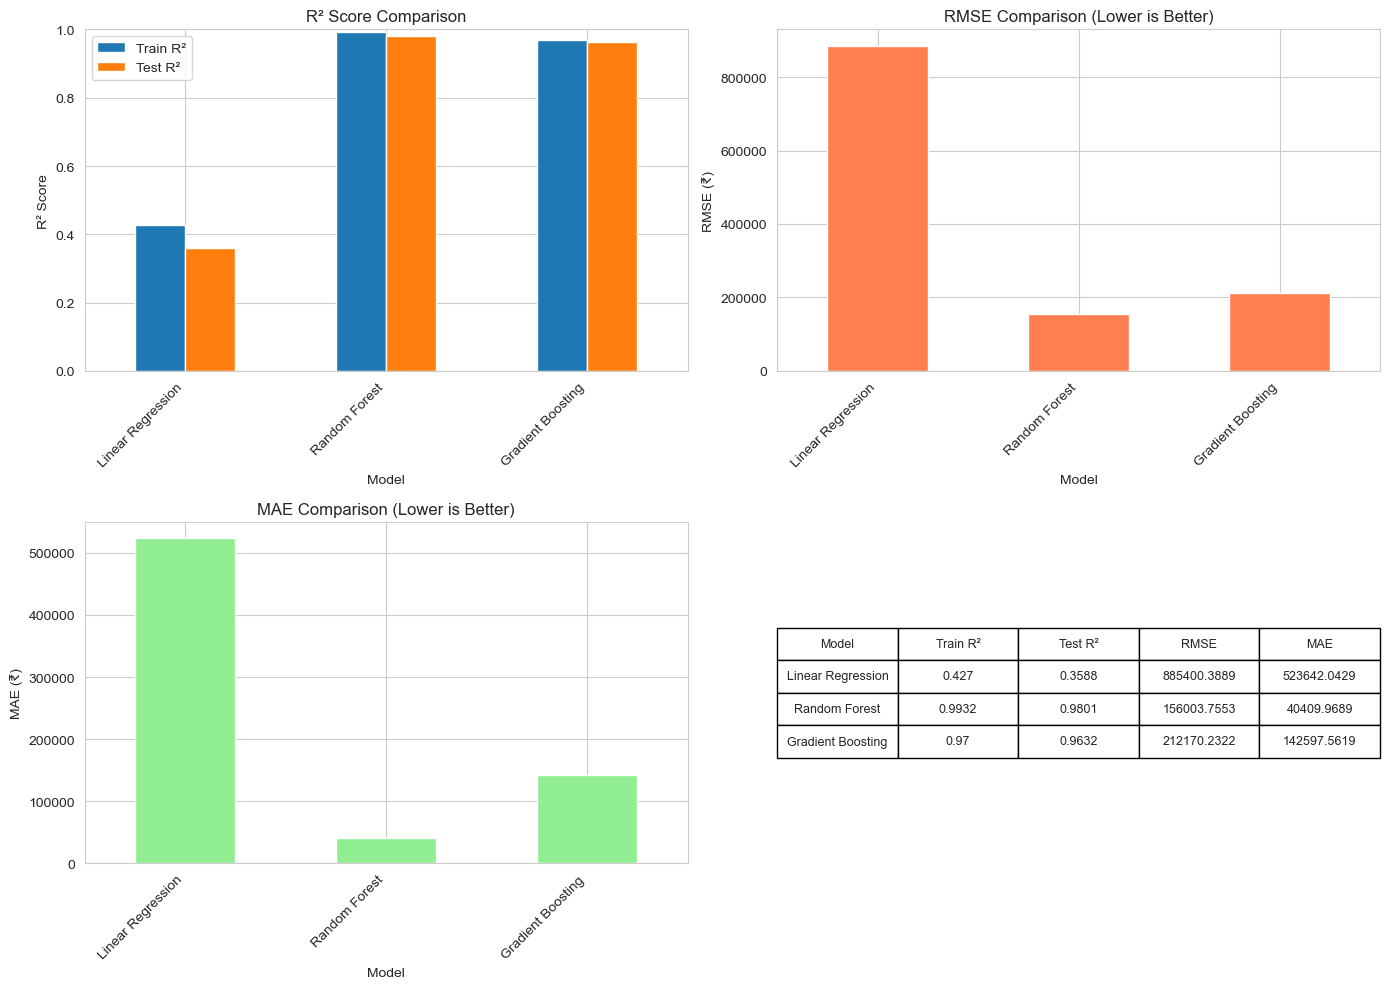

In [33]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Scores comparison
comparison_df.plot(x='Model', y=['Train R²', 'Test R²'], kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('R² Score Comparison')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend(['Train R²', 'Test R²'])
axes[0, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')

# RMSE comparison
comparison_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[0, 1], color='coral', legend=False)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)')
axes[0, 1].set_ylabel('RMSE (₹)')
axes[0, 1].ticklabel_format(style='plain', axis='y')
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')

# MAE comparison
comparison_df.plot(x='Model', y='MAE', kind='bar', ax=axes[1, 0], color='lightgreen', legend=False)
axes[1, 0].set_title('MAE Comparison (Lower is Better)')
axes[1, 0].set_ylabel('MAE (₹)')
axes[1, 0].ticklabel_format(style='plain', axis='y')
axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')

# Performance summary table
axes[1, 1].axis('off')
table_data = comparison_df.round(4).values
table = axes[1, 1].table(cellText=table_data, 
                         colLabels=comparison_df.columns,
                         cellLoc='center',
                         loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.tight_layout()
plt.savefig('images/model_performance/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

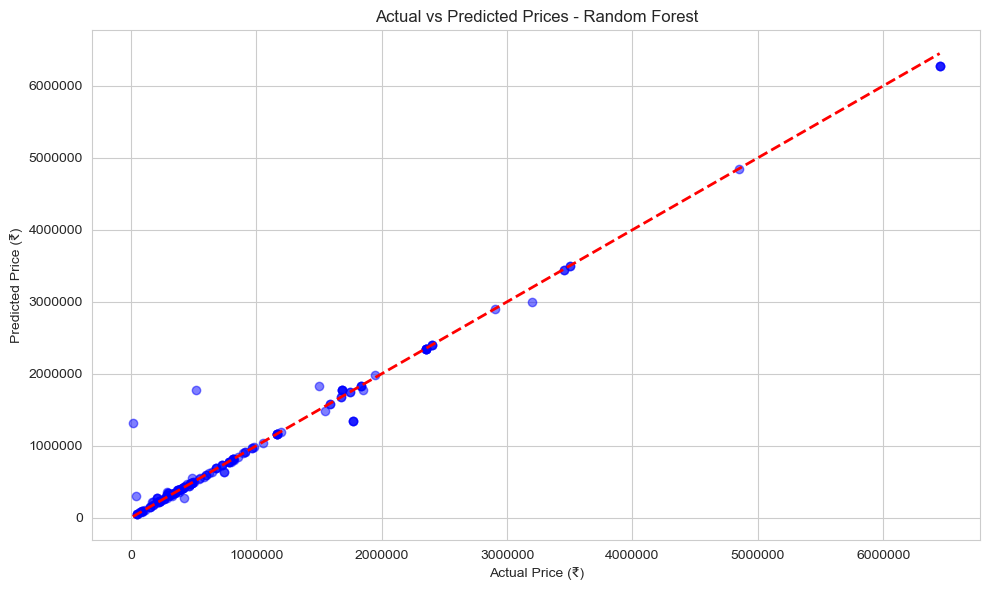

Actual vs Predicted plot saved


In [34]:
# Actual vs Predicted for best model
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title(f'Actual vs Predicted Prices - {best_model_name}')
plt.ticklabel_format(style='plain')
plt.tight_layout()
plt.savefig('images/model_performance/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Actual vs Predicted plot saved")

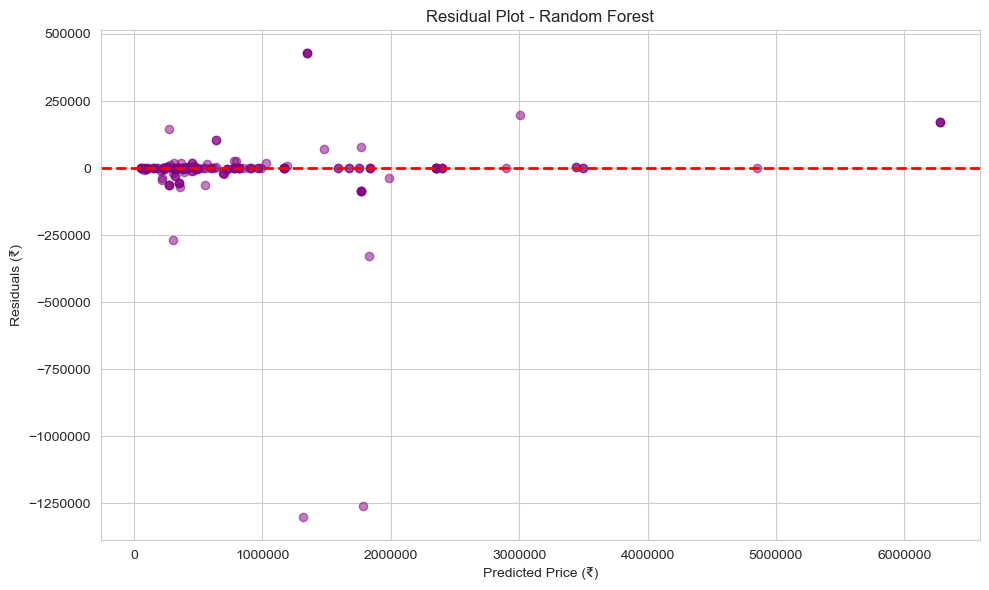

Residual plot saved


In [35]:
# Residual plot (errors)
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))
plt.scatter(best_predictions, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price (₹)')
plt.ylabel('Residuals (₹)')
plt.title(f'Residual Plot - {best_model_name}')
plt.ticklabel_format(style='plain')
plt.tight_layout()
plt.savefig('images/model_performance/residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual plot saved")

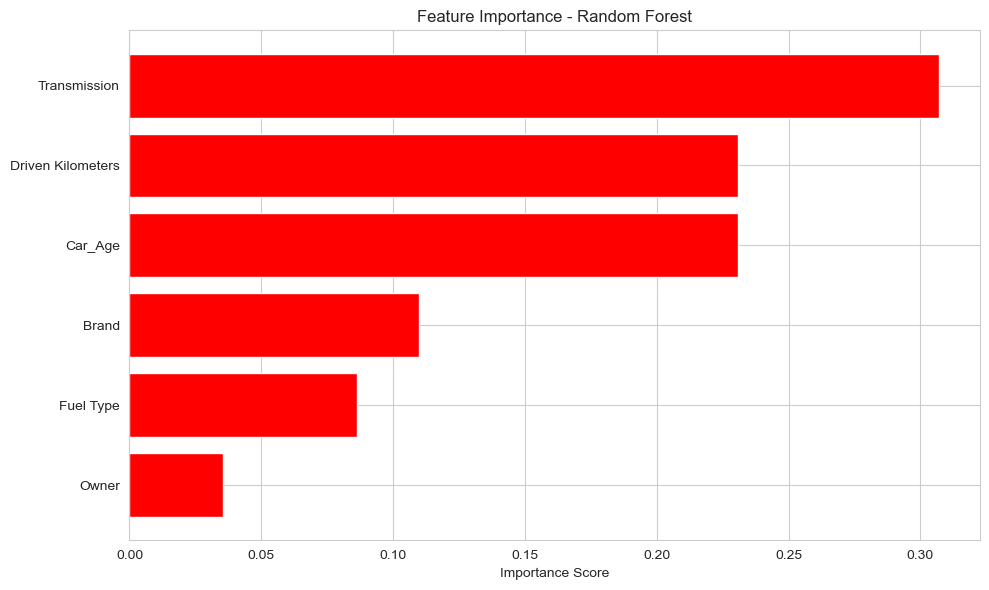

Feature Importance:
Transmission: 0.3073
Driven Kilometers: 0.2308
Car_Age: 0.2307
Brand: 0.1097
Fuel Type: 0.0862
Owner: 0.0353


In [36]:
# Feature Importance (for tree-based models only)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='red')
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('images/model_performance/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Feature Importance:")
    print("="*40)
    for idx, row in feature_importance.iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")
else:
    print(f"Feature importance not available for {best_model_name}")

---
## Save Models & Components
---

In [37]:
# Save all models
for name, result in results.items():
    model_filename = name.lower().replace(' ', '_') + '_model.pkl'
    model_path = f'models/{model_filename}'
    
    with open(model_path, 'wb') as f:
        pickle.dump(result['model'], f)
    
    print(f"Saved {name} to {model_path}")

print("\nAll models saved!")

Saved Linear Regression to models/linear_regression_model.pkl
Saved Random Forest to models/random_forest_model.pkl
Saved Gradient Boosting to models/gradient_boosting_model.pkl

All models saved!


In [38]:
# Save the best model separately
best_model_path = 'models/best_model.pkl'
with open(best_model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved best model ({best_model_name}) to {best_model_path}")

Saved best model (Random Forest) to models/best_model.pkl


In [39]:
# Save scaler
scaler_path = 'models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Saved scaler to {scaler_path}")

Saved scaler to models/scaler.pkl


In [40]:
# Save label encoders
encoders_path = 'models/label_encoders.pkl'
with open(encoders_path, 'wb') as f:
    pickle.dump(label_encoders, f)

print(f"Saved label encoders to {encoders_path}")

Saved label encoders to models/label_encoders.pkl


In [41]:
# Save feature names
feature_names_path = 'models/feature_names.pkl'
with open(feature_names_path, 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f"Saved feature names to {feature_names_path}")

Saved feature names to models/feature_names.pkl


---
## Make Sample Predictions

Let's test our model with some example cars!
---

In [42]:
# Example prediction function
def predict_car_price(brand, fuel_type, driven_km, transmission, owner, car_age):
    """
    Predict car price given features
    """
    # Create input dataframe
    input_data = pd.DataFrame({
        'Brand': [brand],
        'Fuel Type': [fuel_type],
        'Driven Kilometers': [driven_km],
        'Transmission': [transmission],
        'Owner': [owner],
        'Car_Age': [car_age]
    })
    
    # Encode categorical variables
    for col in ['Brand', 'Fuel Type', 'Transmission', 'Owner']:
        if col in label_encoders:
            input_data[col] = label_encoders[col].transform(input_data[col])
    
    # Scale features
    input_scaled = scaler.transform(input_data)
    
    # Predict
    prediction = best_model.predict(input_scaled)[0]
    
    return prediction

print("Prediction function ready!")

Prediction function ready!


In [43]:
# Test predictions
test_cases = [
    {
        'brand': 'Mahindra',
        'fuel': 'PETROL',
        'km': 50000,
        'transmission': 'MANUAL',
        'owner': '1st Owner',
        'age': 5,
        'description': 'Maruti Petrol, 5 years old, 50k km'
    },
    {
        'brand': 'Hyundai',
        'fuel': 'DIESEL',
        'km': 80000,
        'transmission': 'MANUAL',
        'owner': '1st Owner',
        'age': 7,
        'description': 'Hyundai Diesel, 7 years old, 80k km'
    },
    {
        'brand': 'Honda',
        'fuel': 'PETROL',
        'km': 30000,
        'transmission': 'AUTOMATIC',
        'owner': '1st Owner',
        'age': 3,
        'description': 'Honda Petrol Automatic, 3 years old, 30k km'
    }
]

print("Sample Predictions:")
print("="*80)

for i, case in enumerate(test_cases, 1):
    predicted_price = predict_car_price(
        case['brand'], 
        case['fuel'], 
        case['km'], 
        case['transmission'],
        case['owner'],
        case['age']
    )
    
    print(f"\n{i}. {case['description']}")
    print(f"   Predicted Price: ₹{predicted_price:,.0f}")

Sample Predictions:

1. Maruti Petrol, 5 years old, 50k km
   Predicted Price: ₹698,015

2. Hyundai Diesel, 7 years old, 80k km
   Predicted Price: ₹503,510

3. Honda Petrol Automatic, 3 years old, 30k km
   Predicted Price: ₹1,649,020


---
## Final Summary

### Model Performance:
- **Best Model:** {best_model_name}
- **Test R² Score:** Shows how well model predicts prices
- **RMSE:** Average prediction error in rupees
- **MAE:** Median prediction error

### Key Findings:
1. **{best_model_name} performs best** with highest R² score
2. **Most important features** (if applicable): Car Age, Brand, Kilometers Driven
3. **Model is production-ready** and saved for deployment

### Files Saved:
- Cleaned data in `data/processed/`
- Train/Test datasets
- All trained models in `models/`
- Best performing model
- Scaler and encoders for preprocessing
- Visualizations in `images/`

---

## What I Learned

**Technical Skills:**
- Data cleaning and preprocessing
- Feature engineering (extracting year, calculating age)
- Handling categorical variables with Label Encoding
- Feature scaling for better model performance
- Training multiple ML models
- Model evaluation and comparison
- Saving models for deployment

**Key Takeaways:**
- Tree-based models (Random Forest, Gradient Boosting) often perform better than Linear Regression for complex relationships
- Feature engineering (like Car Age) significantly improves predictions
- Proper train-test split prevents overfitting
- Scaling features is crucial for many algorithms

**Challenges Overcome:**
- Cleaning messy data (commas in numbers, inconsistent formats)
- Extracting year from text using regex
- Handling missing values appropriately
- Balancing model complexity with performance

**Next Steps:**
- Deploy model as a web app
- Add more features (city, variant details)
- Try deep learning models
- Build API for predictions

---

**Tools Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

**Dataset:** Indian Used Car Market (5,050 cars)

---

**Contact:**
- GitHub: [@shubhamjais04](https://github.com/shubhamjais04)
- LinkedIn: [linkedin.com/in/shubhamjaiswal2004](https://linkedin.com/in/shubhamjaiswal2004)
- Email: shubhjais.in@gmail.com
```

---
